# **Đồ án Lab 01: Xử lý ảnh bằng Ma trận**

**Môn học:** Toán ứng dụng và thống kê 

**Nhóm sinh viên:** 
- 21120565 - Trần Văn Thông
- 23120248 - Nguyễn Mạnh Hà
- 23120344 - Đặng Dương Thanh Quang
- 23120367 - Trần Ngọc Diễm Thúy
- 23120387 - Nguyễn Duy Tú

---

## **1. Khai báo thư viện và Module**

Chúng em chia dự án thành các module nhỏ để dễ quản lý:
- `basic_ops`: Các phép toán pixel cơ bản.
- `convolution`: Các phép toán tích chập ma trận.
- `edge_detect`: Thuật toán phát hiện biên cạnh.

In [25]:
# ── Cell 1: Import ──────────────────────────────
import importlib
import src.convolution as convolution_module

from src.io_handler import read_image, save_image, show_comparison, show_pipeline, generate_report, matrix_info
from src.basic_ops import brighten, adjust_contrast, to_grayscale
from src.edge_detect import sobel_edges, canny_edges        
importlib.reload(convolution_module)
from src.convolution import gaussian_blur, sharpen

## **2. Đọc dữ liệu ảnh**

Ảnh được đọc dưới dạng ma trận đa chiều (NumPy array) để thực hiện các phép toán đại số tuyến tính.

In [26]:
# ── Cell 2: Đọc ảnh đầu vào ─────────────────────
img = read_image("data/input/sample.jpg", mode="color")

## **3. Tăng sáng bằng phép cộng ma trận**

Ý tưởng là cộng cùng một hằng số vào tất cả pixel. Khi đó toàn bộ ảnh sẽ sáng hơn hoặc tối hơn một cách đồng đều.

Công thức:

`I'(x, y) = I(x, y) + c`

Trong đó:
- `c` là hằng số cộng vào mọi pixel.
    - Nếu `c > 0` thì ảnh sáng lên.
    - Nếu `c < 0` thì ảnh tối đi.


────────────────────────────────────────
  Ảnh sau khi tăng sáng
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 40.00 / 255.00
  Trung bình : 147.22
────────────────────────────────────────


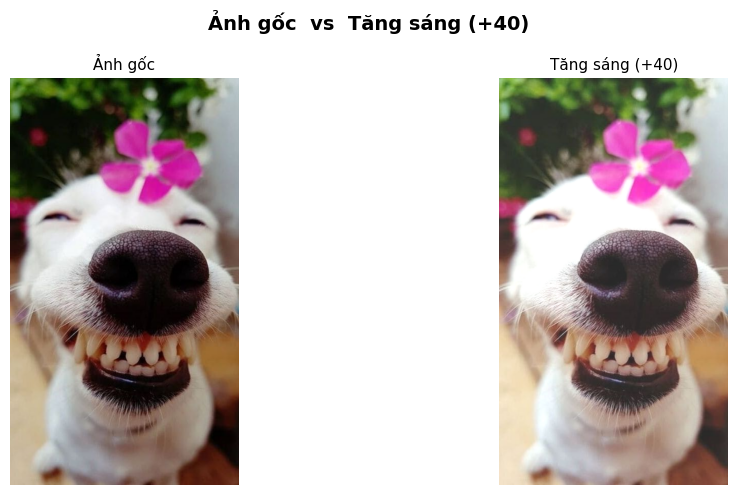

 Đã lưu ảnh: data/output/brightened_sample.jpg


In [27]:
# ── Cell 3: Tăng sáng ───────────────────────────
# Tăng sáng bằng cách cộng một giá trị vào tất cả pixel
brightness_value = 40
bright_image = brighten(img, brightness_value)

# Hiển thị thông tin ma trận và so sánh ảnh
matrix_info(bright_image, label='Ảnh sau khi tăng sáng')
show_comparison(
    img,
    bright_image,
    title_orig='Ảnh gốc',
    title_proc=f'Tăng sáng (+{brightness_value})'
)

# Lưu ảnh đã xử lý
save_image(bright_image, 'data/output/brightened_sample.jpg')

## **4. Điều chỉnh tương phản bằng phép nhân ma trận**

Điều chỉnh tương phản bằng cách nhân toàn bộ ma trận ảnh với một hệ số `k`.

Công thức:

`I'(x, y) = I(x, y) * k`

- Nếu `k > 1` thì mức sáng được khuếch đại mạnh hơn, ảnh nhìn gắt hơn.
- Nếu `0 < k < 1` thì mức sáng bị nén lại, ảnh nhìn dịu hơn.


────────────────────────────────────────
  Ảnh sau khi điều chỉnh tương phản
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 140.21
────────────────────────────────────────


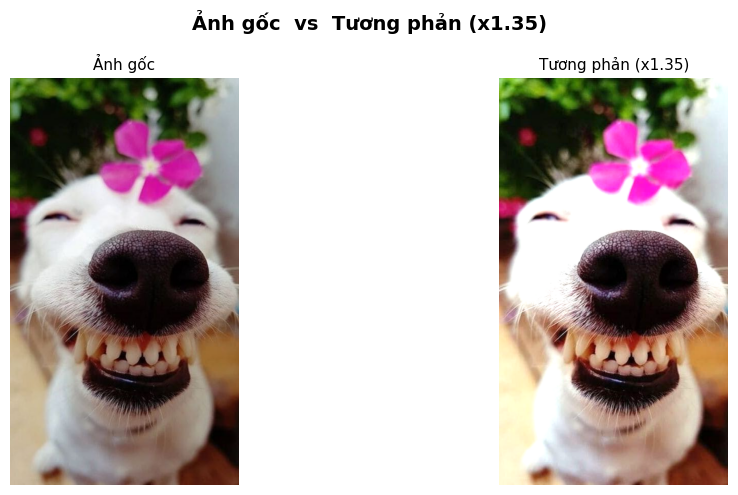

 Đã lưu ảnh: data/output/contrast_sample.jpg


In [28]:
# ── Cell 4: Điều chỉnh tương phản ─────────────────
# Điều chỉnh tương phản bằng cách nhân một hệ số vào tất cả pixel
contrast_factor = 1.35
contrast_image = adjust_contrast(img, contrast_factor)

# Hiển thị thông tin ma trận và so sánh ảnh
matrix_info(contrast_image, label='Ảnh sau khi điều chỉnh tương phản')
show_comparison(
    img,
    contrast_image,
    title_orig='Ảnh gốc',
    title_proc=f'Tương phản (x{contrast_factor})'
)

# Lưu ảnh đã xử lý
save_image(contrast_image, 'data/output/contrast_sample.jpg')

## **5. Chuyển ảnh màu sang ảnh xám bằng tổ hợp tuyến tính**

Ảnh màu gồm 3 kênh B, G, R. Mục tiêu là quy 3 giá trị màu của mỗi pixel về một giá trị mức xám duy nhất.

Do ảnh được đọc theo thứ tự **BGR**, công thức trong phần này được viết theo đúng thứ tự đó:

`Gray = 0.114 * B + 0.587 * G + 0.299 * R`

Đây là phép tổ hợp tuyến tính có trọng số, cho thấy mỗi kênh đóng góp khác nhau vào độ sáng cảm nhận.


────────────────────────────────────────
  Ảnh grayscale
  Kích thước : (800, 450)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 254.00
  Trung bình : 109.27
────────────────────────────────────────


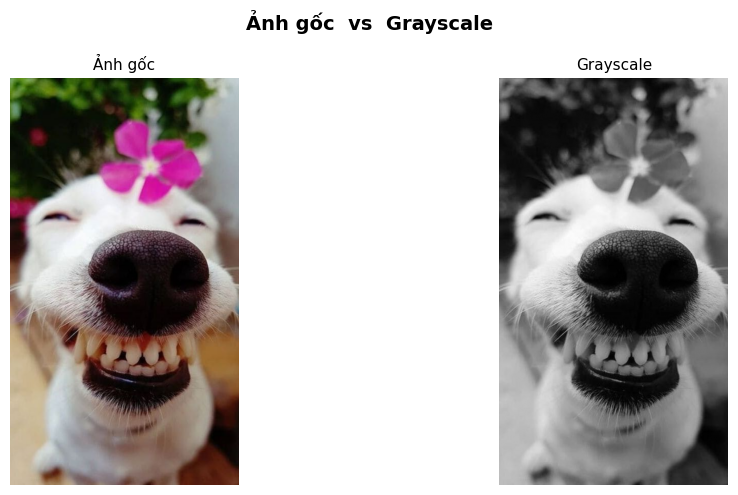

 Đã lưu ảnh: data/output/grayscale_sample.jpg


In [29]:
# ── Cell 5: Chuyển sang grayscale ─────────────────
# Chuyển ảnh màu sang grayscale bằng cách tính trung bình có trọng số của các kênh màu
gray_image = to_grayscale(img)

# Hiển thị thông tin ma trận và so sánh ảnh
matrix_info(gray_image, label='Ảnh grayscale')
show_comparison(
    img,
    gray_image,
    title_orig='Ảnh gốc',
    title_proc='Grayscale',
    cmap='gray'
)

# Lưu ảnh đã xử lý
save_image(gray_image, 'data/output/grayscale_sample.jpg')

## **6. Làm mờ ảnh (Gaussian Blur) bằng tích chập**

Làm mờ giúp giảm nhiễu và làm mịn ảnh bằng cách thay mỗi pixel bằng trung bình có trọng số của vùng lân cận.

Trong Gaussian Blur, trọng số gần tâm lớn hơn, nên ảnh mờ tự nhiên hơn so với trung bình đều.


────────────────────────────────────────
  Ảnh sau khi Gaussian blur
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 253.00
  Trung bình : 108.05
────────────────────────────────────────


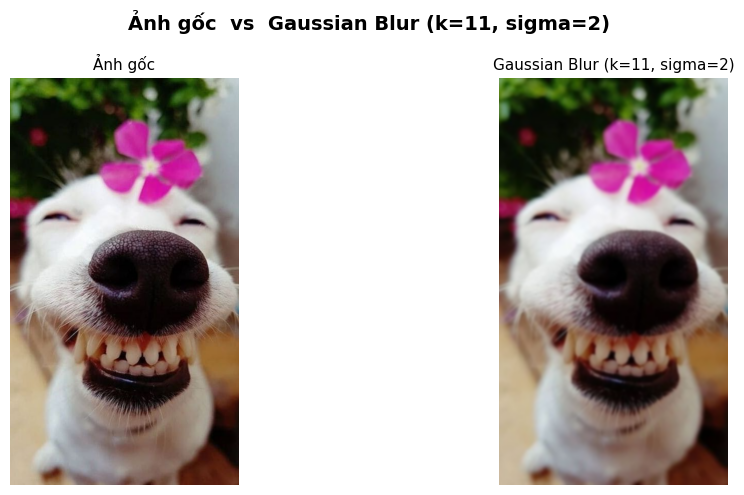

 Đã lưu ảnh: data/output/gaussian_blur_sample.jpg


In [30]:
# ── Cell 6: Gaussian Blur ───────────────────────
# Làm mờ ảnh để giảm nhiễu trước các bước xử lý cao hơn
blur_kernel_size = 11
blur_sigma = 2
blur_image = gaussian_blur(img, kernel_size=blur_kernel_size, sigma=blur_sigma)

matrix_info(blur_image, label='Ảnh sau khi Gaussian blur')
show_comparison(
    img,
    blur_image,
    title_orig='Ảnh gốc',
    title_proc=f'Gaussian Blur (k={blur_kernel_size}, sigma={blur_sigma})'
)

save_image(blur_image, 'data/output/gaussian_blur_sample.jpg')

## **7. Làm sắc nét ảnh (Sharpening) bằng Laplacian**

Làm sắc nét giúp nhấn mạnh đường biên và chi tiết bằng cách tăng cường thành phần biên cạnh trong ảnh.

Ở đây sử dụng công thức kiểu unsharp masking: ảnh gốc cộng với thành phần Laplacian có hệ số điều khiển cường độ.


────────────────────────────────────────
  Ảnh sau khi sharpen
  Kích thước : (800, 450, 3)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 108.87
────────────────────────────────────────


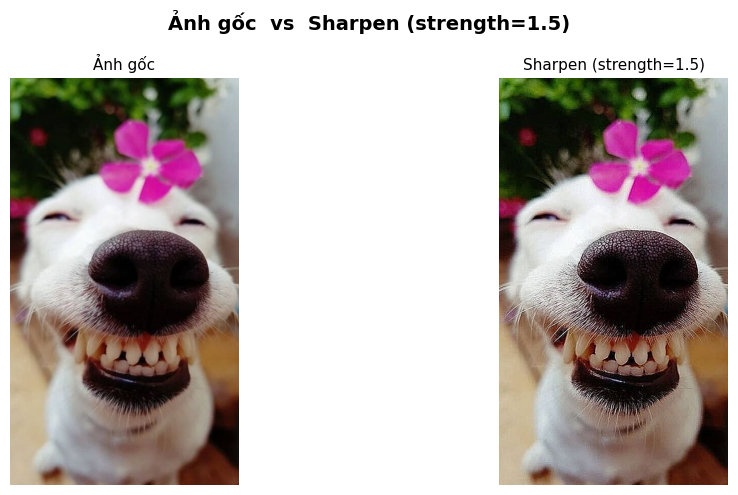

 Đã lưu ảnh: data/output/sharpen_sample.jpg


In [31]:
# ── Cell 7: Sharpening ──────────────────────────
# Làm sắc nét để làm nổi bật chi tiết ảnh
sharpen_strength = 1.5
sharp_image = sharpen(img, kernel_type='laplacian', strength=sharpen_strength)

matrix_info(sharp_image, label='Ảnh sau khi sharpen')
show_comparison(
    img,
    sharp_image,
    title_orig='Ảnh gốc',
    title_proc=f'Sharpen (strength={sharpen_strength})'
)

save_image(sharp_image, 'data/output/sharpen_sample.jpg')

## **8. Phát hiện biên cạnh (Edge Detection) bằng Toán tử Sobel**

### Ý tưởng:

Phát hiện biên cạnh là việc tìm những điểm trong ảnh nơi cường độ sáng **thay đổi mạnh mẽ**. 

Toán tử **Sobel** hoạt động bằng cách tính **gradient** (độ thay đổi) của ảnh theo hai hướng:
- **Hướng X (ngang):** $G_x$ - phát hiện các biên cạnh thẳng đứng
- **Hướng Y (dọc):** $G_y$ - phát hiện các biên cạnh nằm ngang

Các kernel Sobel:

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} \quad G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

### Công thức tính Magnitude (cường độ gradient):

$$G = \sqrt{G_x^2 + G_y^2}$$

Trong đó $G$ là cường độ gradient tại mỗi điểm - nếu $G$ lớn → điểm đó là biên cạnh.

**Ứng dụng:** Phát hiện đường nét, texton trong ảnh; là bước tiền xử lý quan trọng trong Computer Vision.


┌─ Sobel Edge Detection ─┐

────────────────────────────────────────
  Gradient X (Gx)
  Kích thước : (800, 450)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 129.65
────────────────────────────────────────

────────────────────────────────────────
  Gradient Y (Gy)
  Kích thước : (800, 450)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 121.64
────────────────────────────────────────

────────────────────────────────────────
  Magnitude (G = √(Gx² + Gy²))
  Kích thước : (800, 450)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 9.69
────────────────────────────────────────


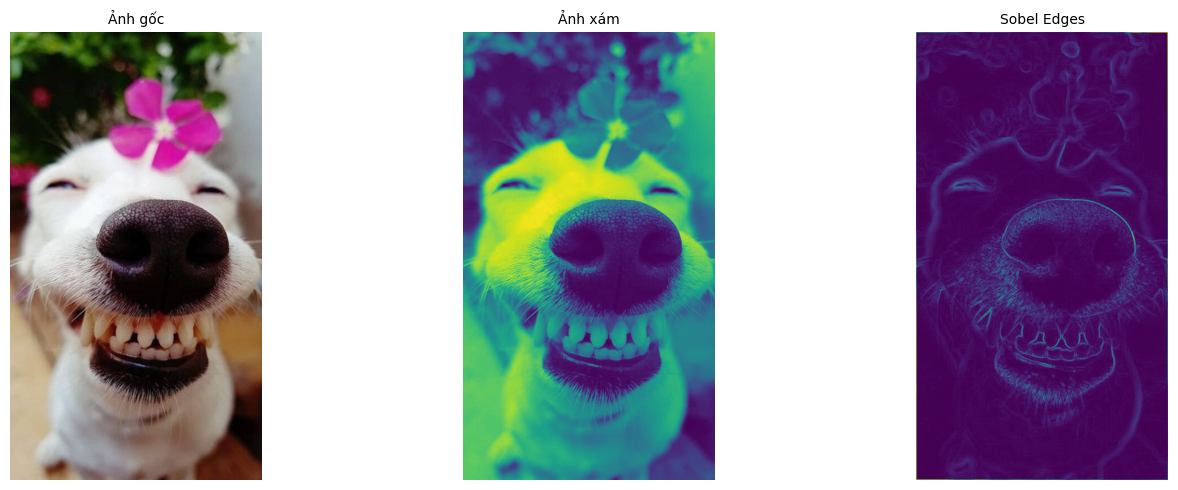

 Đã lưu ảnh: data/output/sobel_gx.jpg
 Đã lưu ảnh: data/output/sobel_gy.jpg
 Đã lưu ảnh: data/output/sobel_magnitude.jpg


In [32]:
# ── Cell 6: Phát hiện biên cạnh (Sobel) ─────────
# Áp dụng Sobel edge detection trên ảnh grayscale
Gx, Gy, magnitude = sobel_edges(gray_image)

# Hiển thị thông tin
print("\n┌─ Sobel Edge Detection ─┐")
matrix_info(Gx, label='Gradient X (Gx)')
matrix_info(Gy, label='Gradient Y (Gy)')
matrix_info(magnitude, label='Magnitude (G = √(Gx² + Gy²))')

# Hiển thị toàn bộ pipeline: Gốc → Grayscale → Sobel Edges
show_pipeline(
    [img, gray_image, magnitude],
    ['Ảnh gốc', 'Ảnh xám', 'Sobel Edges'],
    cmap=None,  # Ảnh gốc là màu
    save_path='data/output/sobel_pipeline.png'
)

# Lưu các kết quả
save_image(Gx, 'data/output/sobel_gx.jpg')
save_image(Gy, 'data/output/sobel_gy.jpg')
save_image(magnitude, 'data/output/sobel_magnitude.jpg')

## **9. Nâng cao: Canny Edge Detection**

**Canny** là một trong những thuật toán phát hiện biên cạnh tốt nhất hiện nay.

**Các bước của Canny:**
1. Làm mượt ảnh (Gaussian blur)
2. Tính gradient bằng Sobel
3. **Non-maximum suppression** - làm mỏng các cạnh
4. **Hysteresis thresholding** - loại bỏ các cạnh yếu

Kết quả: các biên cạnh được xác định chính xác và liên tục.


────────────────────────────────────────
  Canny Edges
  Kích thước : (800, 450)
  Kiểu dữ liệu: uint8
  Min / Max  : 0.00 / 255.00
  Trung bình : 7.16
────────────────────────────────────────
 Đã lưu figure so sánh: data/output/sobel_vs_canny.png


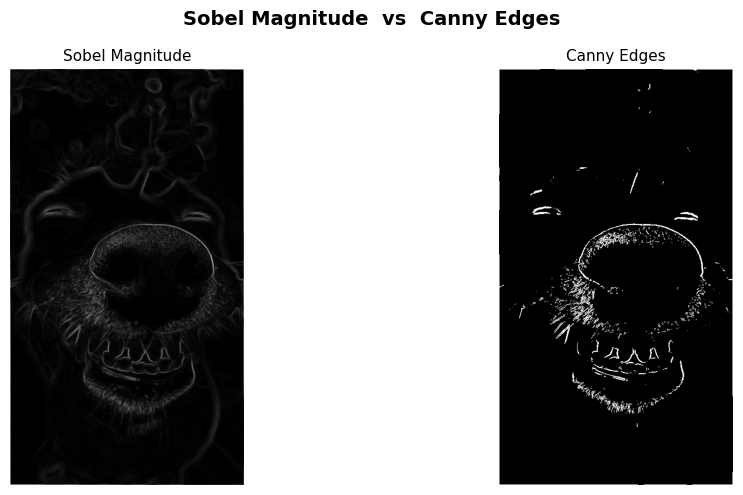

 Đã lưu ảnh: data/output/canny_edges.jpg


In [33]:
# ── Cell 7: Canny Edge Detection (nâng cao) ─────
canny_result = canny_edges(gray_image, low_threshold=5, high_threshold=50)

matrix_info(canny_result, label='Canny Edges')

# So sánh Sobel vs Canny
show_comparison(
    magnitude,
    canny_result,
    title_orig='Sobel Magnitude',
    title_proc='Canny Edges',
    cmap='gray',
    save_path='data/output/sobel_vs_canny.png'
)

save_image(canny_result, 'data/output/canny_edges.jpg')